In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [3]:
df = pd.read_csv('./Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv', encoding='latin-1')
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
print("duplicate transaction_id:", df.duplicated("transaction_id").sum())
print("duplicate user_id:", df.duplicated("user_id").sum())

duplicate transaction_id: 0
duplicate user_id: 0


In [6]:
df["addiction_level"] = df["addiction_level"].fillna("None")

In [7]:
# Weekend uplift
df["weekend_uplift"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
df["weekend_uplift"].describe()

count    7500.000000
mean        1.743915
std         0.719982
min         0.500000
25%         1.130000
50%         1.730000
75%         2.372500
max         3.000000
Name: weekend_uplift, dtype: float64

In [8]:
df["academic_work_impact_numeric"] = np.where(df["academic_work_impact"] == "Yes", 1, 0)

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,weekend_uplift,academic_work_impact_numeric
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0.72,1
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,1.62,1
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,2.62,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,1.94,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,2.59,0


In [9]:
df["stress_level_numeric"] = np.select(
    [
        df["stress_level"] == "Low",
        df["stress_level"] == "Medium",
        df["stress_level"] == "High"
    ],
    [0, 1, 2],
    default=np.nan
)

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,weekend_uplift,academic_work_impact_numeric,stress_level_numeric
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0.72,1,1.0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,1.62,1,1.0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,2.62,0,2.0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,1.94,1,2.0
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,2.59,0,0.0


In [10]:
addiction_mapping = {"None": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
df['addiction_level_numeric'] = df['addiction_level'].map(addiction_mapping)

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,weekend_uplift,academic_work_impact_numeric,stress_level_numeric,addiction_level_numeric
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0.72,1,1.0,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,1.62,1,1.0,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,2.62,0,2.0,1
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,1.94,1,2.0,2
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,2.59,0,0.0,3


In [22]:
df.to_csv("cleanedData.csv", index=False)

In [11]:
# Label consistency
pd.crosstab(df["addicted_label"], df["addiction_level"], dropna=False)

addiction_level,Mild,Moderate,None,Severe
addicted_label,,,,
0,1373,0,819,0
1,0,2874,0,2434


In [12]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,weekend_uplift,academic_work_impact_numeric,stress_level_numeric,addiction_level_numeric
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0.72,1,1.0,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,1.62,1,1.0,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,2.62,0,2.0,1
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,1.94,1,2.0,2
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,2.59,0,0.0,3


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7500.0,26.568800,5.197108,18.00,22.00,27.000,31.0000,35.00
daily_screen_time_hours,7500.0,7.499912,2.609188,3.00,5.22,7.525,9.8100,12.00
social_media_hours,7500.0,3.273484,1.585342,0.50,1.91,3.270,4.6300,6.00
gaming_hours,7500.0,2.014183,1.146039,0.00,1.02,2.040,2.9900,4.00
work_study_hours,7500.0,3.242420,1.600765,0.50,1.85,3.230,4.6400,6.00
sleep_hours,7500.0,6.737561,1.283605,4.50,5.63,6.720,7.8400,9.00
notifications_per_day,7500.0,134.257333,66.586883,20.00,76.00,134.000,191.0000,250.00
app_opens_per_day,7500.0,97.832400,48.423349,15.00,55.00,98.000,140.0000,180.00
weekend_screen_time,7500.0,9.243827,2.718281,3.58,6.96,9.260,11.5400,14.88
addicted_label,7500.0,0.707733,0.454835,0.00,0.00,1.000,1.0000,1.00


In [14]:
df[df["addicted_label"] == 1].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5308.0,26.582894,5.175614,18.00,22.00,27.000,31.00,35.00
daily_screen_time_hours,5308.0,8.467502,2.379855,3.01,6.86,8.840,10.43,12.00
social_media_hours,5308.0,3.695477,1.584817,0.50,2.36,4.060,5.05,6.00
gaming_hours,5308.0,2.020431,1.147780,0.00,1.02,2.055,2.99,4.00
work_study_hours,5308.0,3.243555,1.599095,0.50,1.84,3.230,4.64,6.00
sleep_hours,5308.0,6.766839,1.284231,4.50,5.66,6.760,7.89,9.00
notifications_per_day,5308.0,134.229088,66.721981,20.00,76.00,134.000,192.00,250.00
app_opens_per_day,5308.0,98.175961,48.450802,15.00,56.00,99.000,141.00,180.00
weekend_screen_time,5308.0,10.213994,2.497576,3.66,8.55,10.580,12.16,14.88
addicted_label,5308.0,1.000000,0.000000,1.00,1.00,1.000,1.00,1.00


In [15]:
df[df["addicted_label"] == 0].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2192.0,26.534672,5.249823,18.00,22.0000,27.00,31.0000,35.00
daily_screen_time_hours,2192.0,5.156861,1.349728,3.00,4.0200,5.06,6.0525,8.00
social_media_hours,2192.0,2.251615,1.020967,0.50,1.3600,2.28,3.1000,4.00
gaming_hours,2192.0,1.999051,1.141931,0.01,1.0100,1.99,2.9800,4.00
work_study_hours,2192.0,3.239672,1.605164,0.50,1.8600,3.22,4.6425,6.00
sleep_hours,2192.0,6.666665,1.279607,4.50,5.5700,6.66,7.7400,9.00
notifications_per_day,2192.0,134.325730,66.273727,20.00,77.0000,136.00,191.0000,250.00
app_opens_per_day,2192.0,97.000456,48.357735,15.00,55.0000,97.00,139.0000,180.00
weekend_screen_time,2192.0,6.894535,1.542342,3.58,5.7475,6.79,8.0200,10.81
addicted_label,2192.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00


In [16]:
df.corr(method="pearson",numeric_only=True)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,weekend_uplift,academic_work_impact_numeric,stress_level_numeric,addiction_level_numeric
age,1.000000,0.012767,0.000342,-0.026107,-0.017147,-0.007462,0.000387,-0.002276,0.015286,0.004220,0.011443,-0.014486,0.000955,0.016373
daily_screen_time_hours,0.012767,1.000000,0.010321,0.001140,0.003108,0.019343,0.000811,0.024448,0.964295,0.577112,0.016720,-0.003327,0.013149,0.541402
social_media_hours,0.000342,0.010321,1.000000,-0.000902,-0.002580,0.005947,-0.008593,-0.000371,0.011404,0.414244,0.005651,0.006309,-0.010770,0.385985
gaming_hours,-0.026107,0.001140,-0.000902,1.000000,0.004384,-0.002874,0.015563,-0.009917,-0.006282,0.008485,-0.027849,-0.004645,-0.001744,0.002222
work_study_hours,-0.017147,0.003108,-0.002580,0.004384,1.000000,-0.027150,-0.017518,-0.021676,0.004667,0.001103,0.006354,-0.021702,0.018259,0.000320
sleep_hours,-0.007462,0.019343,0.005947,-0.002874,-0.027150,1.000000,0.016273,0.005692,0.018933,0.035496,0.001384,-0.007841,-0.018851,0.032662
notifications_per_day,0.000387,0.000811,-0.008593,0.015563,-0.017518,0.016273,1.000000,0.004598,-0.002199,-0.000660,-0.011241,0.005386,-0.001932,-0.007484
app_opens_per_day,-0.002276,0.024448,-0.000371,-0.009917,-0.021676,0.005692,0.004598,1.000000,0.021069,0.011041,-0.009053,-0.007385,-0.002314,0.011047
weekend_screen_time,0.015286,0.964295,0.011404,-0.006282,0.004667,0.018933,-0.002199,0.021069,1.000000,0.555426,0.280915,-0.005233,0.011053,0.523358
addicted_label,0.004220,0.577112,0.414244,0.008485,0.001103,0.035496,-0.000660,0.011041,0.555426,1.000000,0.005571,0.000072,-0.007615,0.860163


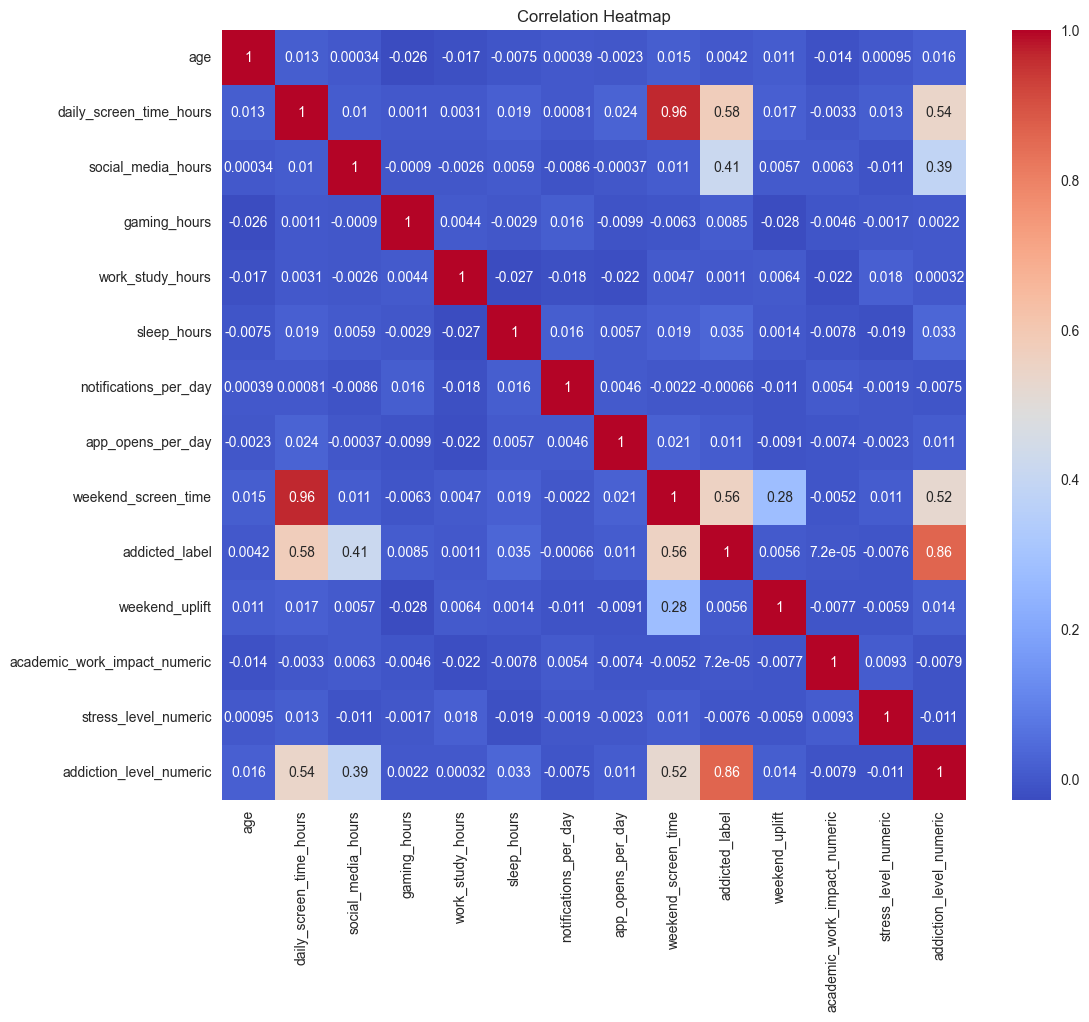

In [17]:
corr = df.corr(method="pearson", numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'social_media_hours'}>,
        <Axes: title={'center': 'gaming_hours'}>],
       [<Axes: title={'center': 'work_study_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'notifications_per_day'}>,
        <Axes: title={'center': 'app_opens_per_day'}>],
       [<Axes: title={'center': 'weekend_screen_time'}>,
        <Axes: title={'center': 'addicted_label'}>,
        <Axes: title={'center': 'weekend_uplift'}>,
        <Axes: title={'center': 'academic_work_impact_numeric'}>],
       [<Axes: title={'center': 'stress_level_numeric'}>,
        <Axes: title={'center': 'addiction_level_numeric'}>, <Axes: >,
        <Axes: >]], dtype=object)

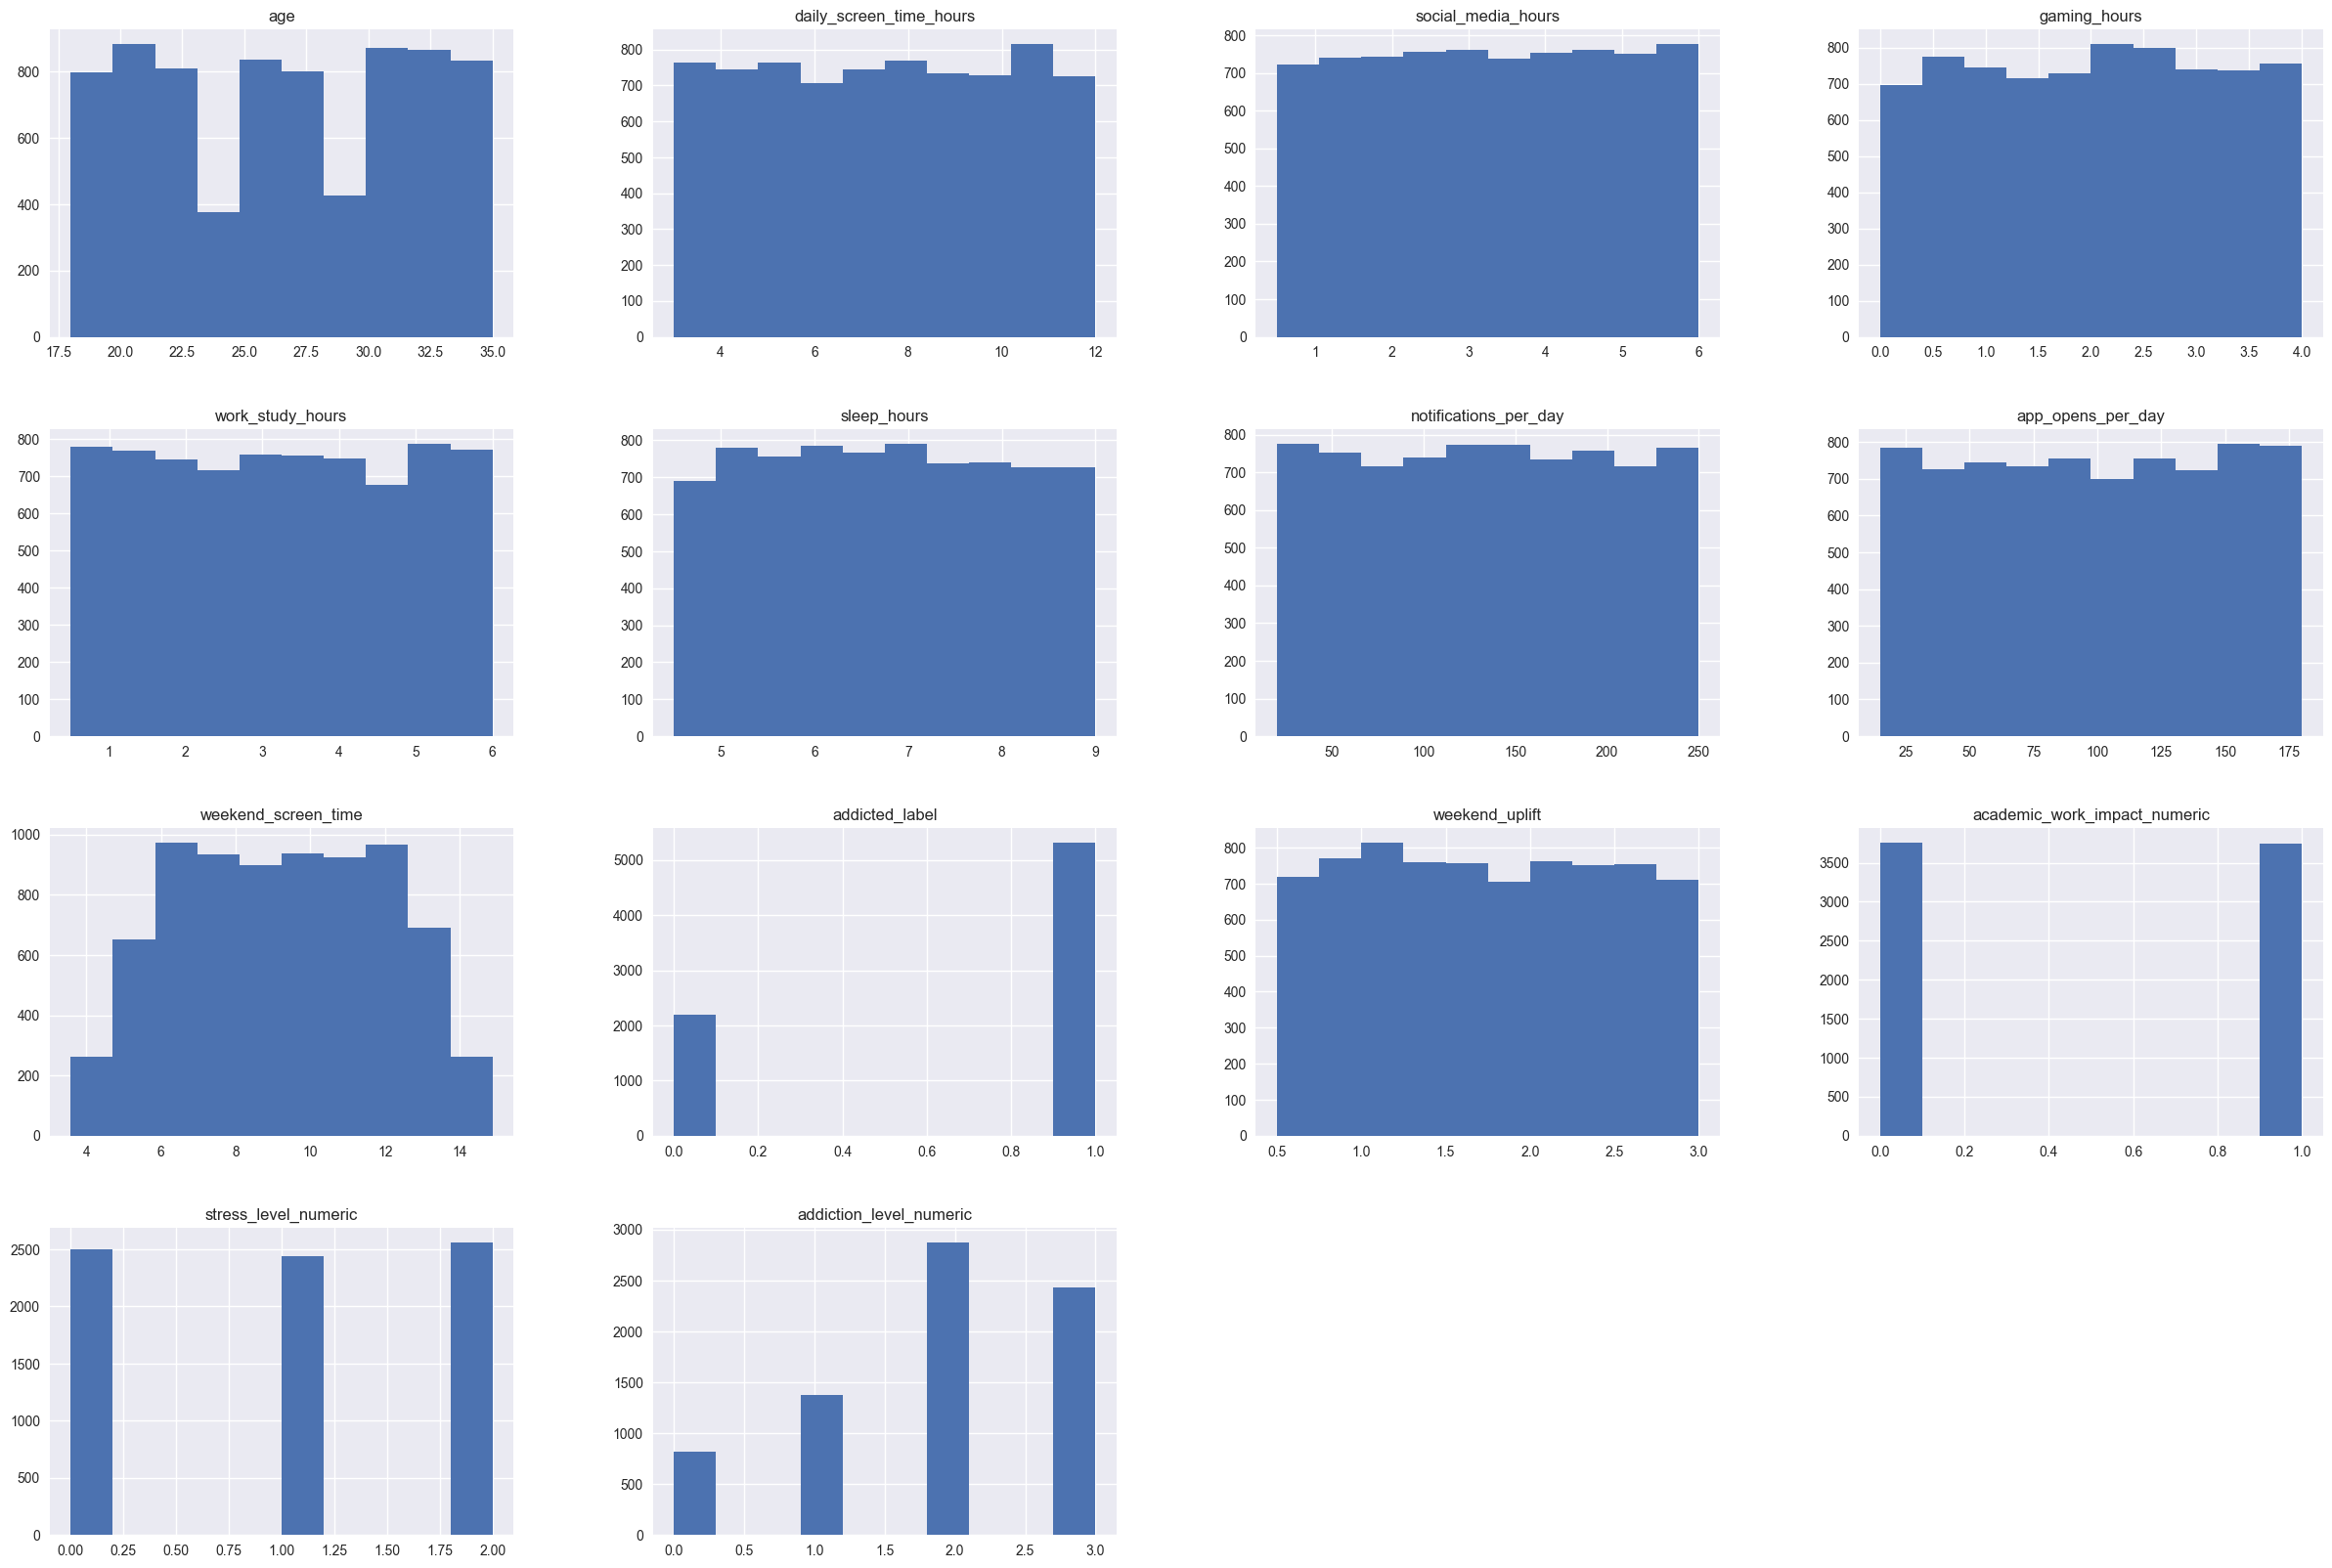

In [18]:
df.hist(figsize=(30,20))

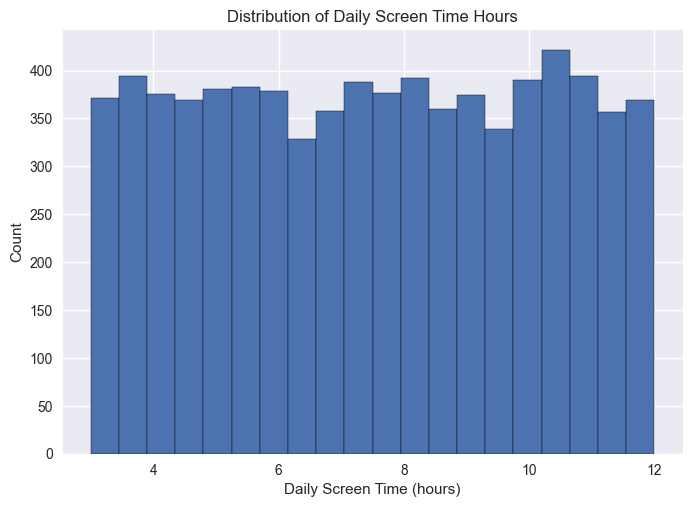

In [19]:
sns.histplot(df['daily_screen_time_hours'], alpha=1, color="C0")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Count")
plt.title("Distribution of Daily Screen Time Hours")
plt.show()

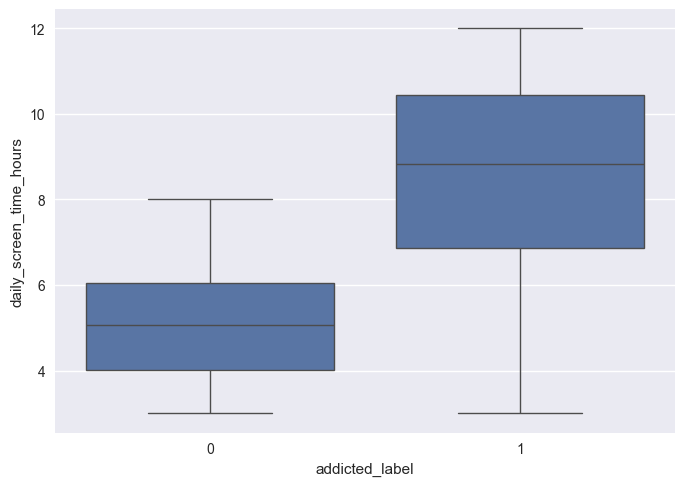

In [20]:
sns.boxplot(x='addicted_label', y='daily_screen_time_hours',data=df,color="C0")
plt.show()

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Page Configuration
st.set_page_config(page_title="Smartphone Addiction Analytics", layout="wide")
st.title("📱 Smartphone Usage & Addiction Dashboard")
st.markdown("---")

# 2. Load and Prepare Data
@st.cache_data
def load_data():
    # Make sure the file name matches exactly
    df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")
    # Feature Engineering
    df["weekend_uplift"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    return df

df = load_data()

# 3. Sidebar Filters
st.sidebar.header("🔍 Filter Options")
gender = st.sidebar.multiselect("Select Gender:", options=df["gender"].unique(), default=df["gender"].unique())
stress_map = {"Low": 0, "Medium": 1, "High": 2}
stress_level = st.sidebar.select_slider("Minimum Stress Level:", options=["Low", "Medium", "High"], value="Low")

# Filtering Logic
mask = (df["gender"].isin(gender)) & (df["stress_level"].map(stress_map) >= stress_map[stress_level])
filtered_df = df[mask]

# 4. Key Performance Indicators (KPIs)
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Users", len(filtered_df))
col2.metric("Avg Screen Time", f"{filtered_df['daily_screen_time_hours'].mean():.1f}h")
col3.metric("Avg App Opens", int(filtered_df['app_opens_per_day'].mean()))
col4.metric("Addiction Rate", f"{(filtered_df['addicted_label'].mean()*100):.1f}%")

st.markdown("---")

# 5. Visualizations
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("📊 Distribution of Daily Screen Time")
    fig1, ax1 = plt.subplots()
    sns.histplot(filtered_df['daily_screen_time_hours'], kde=True, color="#3498db", ax=ax1)
    ax1.set_xlabel("Hours per Day")
    st.pyplot(fig1)

with col_right:
    st.subheader("📈 Stress Level vs. Screen Time")
    fig2, ax2 = plt.subplots()
    sns.boxplot(x='stress_level', y='daily_screen_time_hours', data=filtered_df, palette="Blues", ax=ax2)
    ax2.set_xlabel("Stress Level")
    ax2.set_ylabel("Daily Screen Time (Hours)")
    st.pyplot(fig2)

st.markdown("---")
st.info("Data processed and analyzed using Python and Streamlit.")

Writing app.py
